##### 第一次讀書會專案：針對PTT軍事版以及八卦版中對於美國出兵伊朗相關文章之情緒分析
##### 組別：Group_3
##### 組員：
* M144020008 洪宏林
* M144020017 陳姿佑
* M144020019 顏志豪
* M144020058 黄鈞浩
* M144020002 吳俊廷
* M144020028 白茗仁
* M144020061 黃博章
* B124020008 李怡君
##### 詳細檔案可到：https://github.com/Sylvan945/Social_Network_Analysis_Group_3

##### 專案動機：
1.	國際危機下的社會： 2026年3月初，伊朗局勢成為國際焦點，短短 20 天內在 PTT 雙看板（八卦版、戰爭版）湧現逾兩千篇文章。面對遠在天邊的中東衝突，台灣網友的反應並非漠不關心，而是投射了強烈的情緒。透過情緒分析，我們能捕捉到這些隱藏在文字背後的社會集體心理狀態。

2.	辨識「客觀事實」與「主觀感受」的落差： 傳統新聞媒體多以客觀角度報導戰況與國際角力，但 PTT 論壇則充滿了網民的主觀感受（如：對第三次世界大戰的恐慌、對油價飆漲的焦慮、或是用黑色幽默與反串來面對危機）。分析這些文本情緒，有助於我們了解未經修飾的真實民意。

3.	社群同溫層的情緒渲染： PTT 是一個高度互動的匿名社群，特定事件往往會引發情緒的快速傳染與極化。了解網民在面對戰爭議題時，是傾向理性分析、恐慌焦慮，還是嘲諷看戲，對於研究網路輿論傳播與群眾心理具有高度價值。

##### 1.資料介紹
##### 資料來源：
* Python爬蟲收集PTT平台上與《伊朗》相關的文章
* 來源：戰爭版/八卦版
* 關鍵字：伊朗
* 時間： 2026/03/01~2026/03/20
* 資料筆數：共 2080篇文章




#### 2.1 初始設定

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import re
import jieba
import jieba.analyse
import math
from nltk import ngrams, FreqDist
from collections import Counter, namedtuple

import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
#if not os.path.exists('font.ttf'):
#    !wget -O font.ttf https://github.com/google/fonts/raw/main/ofl/notosanstc/NotoSansTC%5Bwght%5D.ttf

font_path = './font.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'Noto Sans TC'
# 確保圖表中的負號 (-) 能正常顯示
plt.rcParams['axes.unicode_minus'] = False
print("字體設定完成！")

字體設定完成！


In [3]:
#or system font
system_font = r"C:/Windows/Fonts/msjh.ttc"
prop = fm.FontProperties(fname=system_font)
plt.rcParams['font.sans-serif']=['Microsoft JhengHei']

#### 2.2 讀取與基本清洗

In [4]:
# 讀取檔案
df = pd.read_csv('../data/ptt_iran_20260301_0410_full.csv')
clear_df = df.copy() # 複製一份資料進行清洗，保留原始資料以供對照

# 定義並去除分析時用不到的系統與詮釋資料欄位
drop_cols = ['system_id', 'artCatagory', 'artUrl', 'artPoster', 'insertedDate','artComment','dataSource']
clear_df.drop(drop_cols, axis=1, inplace=True, errors='ignore')

# 移除內文 (artContent) 為空值的資料行
clear_df.dropna(subset=['artContent'], inplace=True)

clear_df.head()

,artTitle,artDate,artContent
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...
1,[情報] 幾則關於伊朗戰爭的民調,2026-04-10 16:20:52,https://x.com/NateSilver538/status/20398397434...
2,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,2026-04-10 15:54:15,大西洋期刊，我對這篇文章不予置評，僅供參考\nhttps://x.com/shustry/s...
3,[情報] 報導稱以色列軍方認為伊朗政府更為極端,2026-04-10 15:42:14,https://x.com/Osinttechnical/status/2042422868...
4,[新聞] 曾嗆發展核武，伊朗前外長傷重不治,2026-04-10 14:09:37,曾揚言發展核武！伊朗前外長哈拉齊遇襲亡 住所遭攻擊妻也罹難\n\n\n\n伊朗媒體報導，前伊...


##### 2.3 PTT 專屬進階文字清理

In [5]:

def clean_ptt_text(text):
    """清理 PTT 文章中常見的雜訊 (網址、簽名檔、引言等)"""
    text = str(text)
    
    # 1. 移除網址 (你原本的寫法很好)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 2. 移除 PTT 常見結尾資訊 (發信站、文章網址、編輯記錄)
    # 只要是 "※" 開頭且後面跟著這三個關鍵字，整行連同後面的內容都砍掉
    text = re.sub(r'※ (發信站|文章網址|編輯).*', '', text)
    
    # 3. 移除回文引述
    text = re.sub(r'引述《.*》之銘言', '', text)
    
    # 4. 移除標題標籤，例如 [新聞]、[爆卦]
    text = re.sub(r'\[.*?\]', '', text)
    
    # 5. 移除回文時常見的引言符號 (PTT 每行引言常以 : 或 > 開頭)
    text = re.sub(r'^[>:]\s*', '', text, flags=re.MULTILINE)
    
    # 6. 移除純英文和數字 (依你原本的邏輯保留)
    text = re.sub(r'[a-zA-Z0-9]+', '', text)
    
    # 7. 清除常見的無意義連續符號，例如 --, //, ==, ~~
    text = re.sub(r'[-/=_~]{2,}', '', text)
    
    # 8. 換行轉句號
    text = re.sub(r'\n+', '。', text)
    
    return text

# 將清理函式套用到內文欄位
clear_df['sentence'] = clear_df['artContent'].apply(clean_ptt_text)

# 在斷句前，先將目前的 index 存成 'doc' 欄位，這樣斷句後編號才會留著
clear_df['doc'] = clear_df.index
# 斷句：利用標點符號將整篇文章切分成一句一句的短句
clear_df['sentence'] = clear_df['sentence'].str.split(r"[,，。！!？?]+")
# explode 會將串列中的句子拆解成多列，重置索引
sent_df = clear_df.explode('sentence').reset_index(drop=True)
# 濾除只有 1 個字或全空的無效短句
sent_df = sent_df[sent_df["sentence"].str.len() > 1]

print("\n=== 文字清理與斷句完成 ===")
print(f"目前總共切出了 {len(sent_df)} 句短句準備進行斷詞！")

sent_df


=== 文字清理與斷句完成 ===
目前總共切出了 133843 句短句準備進行斷詞！


,artTitle,artDate,artContent,sentence,doc
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞出處：,0
1,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞內容摘要：,0
2,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行,0
3,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,萬眾矚目的談判,0
4,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,外媒披露,0
...,...,...,...,...,...
143565,[問卦] 愛潑斯坦被戳的小孩跟被炸死的伊朗哪個慘,2026-03-01 00:06:26,如題，\n\n有人說艾波斯坦給小孩錢，\n還有花錢請人生嬰兒來吃，\n很邪惡。\n\n\n可...,卻不承認自己沒資格,3545
143568,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026-03-01 00:01:58,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,以色列電視台頻道快訊說,3546
143569,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026-03-01 00:01:58,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,伊朗精神導師哈米尼已身亡,3546
143570,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026-03-01 00:01:58,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,所以戰爭要結束了嗎,3546


##### 2.4 文章斷詞與整理

In [6]:
# 設定繁體中文字典
jieba.set_dictionary('../dict/dict.txt')

# 加入專案關鍵字，避免斷詞時被切碎
custom_words = ['防衛隊', '革命衛隊', '無人機', '核設施', '哈瑪斯', '真主黨', '中東', '大馬士革', '德黑蘭','哈梅內伊','霍爾木茲海峽','荷姆茲海峽','荷莫茲海峽']
for w in custom_words:
    jieba.add_word(w)

# 讀取停用字清單
with open('../dict/stopwords.txt', encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

# 定義斷詞邏輯：過濾停用字與長度小於 2 的詞
def getToken(row):
    seg_list = jieba.lcut(row)
    return [w for w in seg_list if w not in stopWords and len(w.strip()) > 1]

# 執行斷詞並將結果展開成長表格 (word_df)
word_df = sent_df.assign(word = sent_df['sentence'].apply(getToken)).explode('word')
word_df = word_df.dropna(subset=['word'])

# 檢查產出的總詞數與前幾筆資料
print(f"目前總詞數：{len(word_df)}")
word_df.head()

Building prefix dict from C:\Users\justi\OneDrive\文件\中山碩士\社媒\Social_Network_Analysis_Group_3-main\groupwork1\dict\dict.txt ...
Loading model from cache C:\Users\justi\AppData\Local\Temp\jieba.udc7204813631843afa05e3036a1d0e08.cache
Loading model cost 0.475 seconds.
Prefix dict has been built successfully.


目前總詞數：491727


,artTitle,artDate,artContent,sentence,doc,word
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞出處：,0,新聞
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞出處：,0,出處
1,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞內容摘要：,0,新聞
1,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞內容摘要：,0,內容
1,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞內容摘要：,0,摘要


##### 2.5 最終停用字過濾

In [7]:
# 讀取停用字檔
try:
    with open('/content/stopwords.txt', 'r', encoding='utf-8') as f:
        stopwords = set([line.strip() for line in f])
except FileNotFoundError:
    stopwords = set()

if 'stopWords' not in locals():
    stopWords = list(stopwords)

# 更新手動停用字名單
stopwords_manual = {"-----", "----", "連結", "嘖嘖", "醒醒", "裝睡", "衛生紙", "乳摸", "高潮", "新聞", "內文", "備註", "刪除", "完整", "轉載", "編輯", "張貼", "署名", "文章", "標題", "報導", "八卦", "看板", "作者", "時間", "來源", "內容", "媒體", "情況", "問題", "如題", "原因", "網址", "發信", "實業", "cc", "ptt", "gossiping", "www", "com", "https", "http", "share", "url", "index", "html", "bbs", "status","表示", "行動", "國家", "當作", "出現", "晚間", "政府","目前","請放", "最後", "違者", "未滿", "繁體", "中文字", "水桶", "一天", "以天", "單位",'網友', '點擊'}
stopWords.extend(list(stopwords_manual))

stopWords = list(set(stopWords))

# 執行過濾 (將過濾後的結果存回 word_df)
word_df = word_df[~word_df['word'].isin(stopWords)]


In [8]:
print("=== 🧹 去除停用字後的 TOP 20 關鍵字 ===")
clean_top_words = word_df['word'].value_counts().head(20)
print(clean_top_words)

# 觀察方法 B：隨機抽樣看幾筆資料的長相
print("\n=== 🎲 word_df 隨機抽樣 5 筆 ===")
# 使用 sample() 而不是 head()，可以更客觀地看到分散在各處的詞彙
print(word_df[['doc', 'word']].sample(5))

=== 🧹 去除停用字後的 TOP 20 關鍵字 ===
word
伊朗     20745
美國     10189
川普      5460
以色列     4178
戰爭      3457
攻擊      2636
美軍      2560
中國      2227
飛彈      2216
軍事      1831
現在      1810
總統      1681
目標      1567
中東      1554
無人機     1534
打擊      1455
官員      1390
台灣      1211
談判      1208
政權      1189
Name: count, dtype: int64

=== 🎲 word_df 隨機抽樣 5 筆 ===
         doc word
63307   1164   南部
140381  3418  幾十年
27307    389   美軍
54101    889   軍事
48543    781   毛寧


##### 2.6 同義詞替換

In [9]:
synonyms = {
    '哈梅內伊': '哈米尼',
    'Donald Trump': '川普',
    '阿川': '川普',
    '川皇': '川普',
    '荷莫茲':'荷姆茲',
    '霍爾木茲': '荷姆茲'
}
word_df['word'] = word_df['word'].replace(synonyms)

##### 3.1 計算TF-IDF

######計算各文章詞彙數與 TF 值

In [10]:
# 1. 計算每篇文章的總詞數
total_words = word_df.groupby(['doc'], as_index=False).size().rename(columns={'size': 'total'})

# 2. 重新計算各文章內，每個詞彙出現的次數
word_count = word_df.groupby(['doc', 'word'], as_index=False).size()
word_count.rename(columns={'size': 'count'}, inplace=True)

# 3. 合併總詞數產生 sample_merged
sample_merged = word_count.merge(total_words, on='doc', how='left')

# 4. 計算 TF 值
sample_tf_idf = sample_merged.assign(tf = sample_merged["count"] / sample_merged["total"])

# 5. 檢查結果
sample_tf_idf.head()

,doc,word,count,total,tf
0,0,一道,1,136,0.007353
1,0,上空,1,136,0.007353
2,0,中央社,1,136,0.007353
3,0,主場,1,136,0.007353
4,0,今日,1,136,0.007353


In [11]:
# 依照文章編號 (doc) 分組，計算每篇文章總共切出了多少個詞
total_words = word_df.groupby(['doc'], as_index=False).size().rename(columns={'size': 'total'})

total_words.head()

# 計算每個詞彙出現在多少篇文章中 (Document Frequency)
idf_df = sample_merged.groupby(['word'], as_index=False).size()

# 將出現篇數合併回主表
sample_tf_idf = sample_tf_idf.merge(idf_df, on='word', how='left')

# 計算 IDF = log10( 總文章數 / 包含該詞的文章數 )
# 使用 math.log(x, 10) 代表以 10 為底的對數
N = len(total_words)
sample_tf_idf = sample_tf_idf.assign(
    idf = sample_tf_idf["size"].apply(lambda size: math.log(N / size, 10))
).drop(["size"], axis=1)

# 檢查合併 IDF 後的結果
sample_tf_idf.head()

,doc,word,count,total,tf,idf
0,0,一道,1,136,0.007353,2.508346
1,0,上空,1,136,0.007353,1.717230
2,0,中央社,1,136,0.007353,1.641254
3,0,主場,1,136,0.007353,2.850769
4,0,今日,1,136,0.007353,1.868497


######計算 IDF 值

In [12]:
# 計算每個詞彙出現在多少篇文章中 (Document Frequency)
idf_df = sample_merged.groupby(['word'], as_index=False).size()

# 將出現篇數合併回主表
sample_tf_idf = sample_tf_idf.merge(idf_df, on='word', how='left')

# 計算 IDF = log10( 總文章數 / 包含該詞的文章數 )
# 使用 math.log(x, 10) 代表以 10 為底的對數
N = len(total_words)
sample_tf_idf = sample_tf_idf.assign(
    idf = sample_tf_idf["size"].apply(lambda size: math.log(N / size, 10))
).drop(["size"], axis=1)

# 檢查合併 IDF 後的結果
sample_tf_idf.head()

,doc,word,count,total,tf,idf
0,0,一道,1,136,0.007353,2.508346
1,0,上空,1,136,0.007353,1.717230
2,0,中央社,1,136,0.007353,1.641254
3,0,主場,1,136,0.007353,2.850769
4,0,今日,1,136,0.007353,1.868497


######計算 TF-IDF 並選出文章關鍵詞

In [13]:
# 計算 TF-IDF = TF * IDF
sample_tf_idf = sample_tf_idf.assign(tf_idf = sample_tf_idf["tf"] * sample_tf_idf["idf"])

# 依照 TF-IDF 分數排序，查看全資料集權重最高的詞
print("--- 全資料集權重前 10 名 ---")
display(sample_tf_idf.sort_values('tf_idf', ascending=False).head(10))

# 提取每篇文章 TF-IDF 值最高的前三個詞 (作為文章標籤)
print("\n--- 每篇文章的關鍵詞 (Top 3) ---")
group_keywords = sample_tf_idf.groupby("doc").apply(lambda x: x.nlargest(3, "tf_idf"), include_groups=False)
group_keywords.head(15)

--- 全資料集權重前 10 名 ---


,doc,word,count,total,tf,idf,tf_idf
26042,161,該機,1,2,0.500000,2.947679,1.473839
26041,161,彈射,1,2,0.500000,2.345619,1.172809
192181,1923,喔喔,10,28,0.357143,3.248709,1.160253
311393,3528,飯店,2,6,0.333333,2.087341,0.695780
76712,520,第天,2,6,0.333333,1.993436,0.664479
311510,3535,火柴,1,5,0.200000,3.248709,0.649742
180560,1749,天使,9,43,0.209302,2.947679,0.616956
20927,132,戰敗,3,11,0.272727,2.227519,0.607505
222137,2316,機械,4,19,0.210526,2.850769,0.600162
76710,520,插圖,1,6,0.166667,3.549739,0.591623



--- 每篇文章的關鍵詞 (Top 3) ---


word  count  total        tf       idf    tf_idf
doc                                                      
0   34   巴基斯坦      9    136  0.066176  1.403611  0.092886
    35     巴德      3    136  0.022059  2.188011  0.048265
    63     空域      3    136  0.022059  2.031225  0.044806
1   125    民調      4     66  0.060606  1.886981  0.114362
    124    民眾      6     66  0.090909  1.233768  0.112161
    118   支持度      3     66  0.045455  2.248709  0.102214
2   314    晶片      7    525  0.013333  2.345619  0.031275
    213    台灣     17    525  0.032381  0.814939  0.026388
    243    封鎖     12    525  0.022857  1.027294  0.023481
3   483    另稱      1     31  0.032258  2.850769  0.091960
    502    軍方      2     31  0.064516  1.164132  0.075105
    500    著手      1     31  0.032258  2.319290  0.074816
4   534    哈拉      4    149  0.026846  3.549739  0.095295
    600    老人      2    149  0.013423  2.345619  0.031485
    559   德黑蘭      5    149  0.033557  0.896526  0.030085

##### 3.2 建立 DTM 格式資料集

In [14]:
# 1. 複製一份資料進行 DTM 分析
ptt_dtm_df = df.copy()

# 2. 保留需要的欄位，並填補空值
ptt_dtm_df['artContent'] = ptt_dtm_df['artContent'].fillna('')

# 3. 確保只取需要的欄位
ptt_dtm_df = ptt_dtm_df.loc[:, ["artTitle", "artContent"]]

ptt_dtm_df['cleaned_content'] = ptt_dtm_df['artContent'].apply(clean_ptt_text)

# 4. 執行斷詞並用空格串接
ptt_dtm_df['word'] = ptt_dtm_df['cleaned_content'].apply(getToken).map(' '.join)

# 檢查結果
ptt_dtm_df.head()

,artTitle,artContent,cleaned_content,word
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞出處：。新聞內容摘要：。（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯...,出處 摘要 中央社 新德里 綜合 外電 美國 伊朗 將於日 巴基斯坦 首都 伊斯蘭 巴德 舉...
1,[情報] 幾則關於伊朗戰爭的民調,https://x.com/NateSilver538/status/20398397434...,。根據 的統整各間民調，。可見美國民眾對伊朗戰爭的支持度持續下滑。皮尤民調，追蹤美國民眾對以...,統整 各間 民調 美國 民眾 伊朗 戰爭 支持度 持續 下滑 民調 追蹤 美國 民眾 以色列...
2,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,大西洋期刊，我對這篇文章不予置評，僅供參考\nhttps://x.com/shustry/s...,大西洋期刊，我對這篇文章不予置評，僅供參考。中國從伊朗戰爭中學到了什麼。對台灣實施封鎖，對全...,大西洋 期刊 這篇 不予置評 參考 中國 伊朗 戰爭 中學 台灣 實施 封鎖 全球 經濟 造...
3,[情報] 報導稱以色列軍方認為伊朗政府更為極端,https://x.com/Osinttechnical/status/2042422868...,。以色列媒體報導。以色列軍方告訴國會議員說伊朗的新政府比戰前的更極端。以色列軍方另稱作戰對伊...,以色列 以色列 軍方 告訴 國會 議員 伊朗 戰前 以色列 軍方 另稱 作戰 伊朗 造成 嚴...
4,[新聞] 曾嗆發展核武，伊朗前外長傷重不治,曾揚言發展核武！伊朗前外長哈拉齊遇襲亡 住所遭攻擊妻也罹難\n\n\n\n伊朗媒體報導，前伊...,曾揚言發展核武！伊朗前外長哈拉齊遇襲亡 住所遭攻擊妻也罹難。伊朗媒體報導，前伊朗外交部長哈拉...,揚言 發展 核武 伊朗 外長 拉齊 遇襲 住所 攻擊 罹難 伊朗 伊朗 外交部長 哈拉 美國...


In [15]:
# 1. 限制詞彙量：只取詞頻前 1000 高的詞
# 2. 移除太冷門的詞：至少要在 5 篇文章出現過
vectorizer = CountVectorizer(max_features=1000, min_df=5)

# 重新學習與轉換
X = vectorizer.fit_transform(ptt_dtm_df["word"])
vocabulary = vectorizer.get_feature_names_out()

# 轉換成 DataFrame
DTM_df = pd.DataFrame(columns=vocabulary, data=X.toarray())
DTM_df.head()

,一下,一份,一位,一名,一堆,一場,一枚,一架,一次,一段,...,飛行員,首次,首都,體制,體系,高層,高度,高級,鵝肝,黎巴嫩
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [16]:
# 1. 初始化轉換器
transformer = TfidfTransformer()

# 2. 將剛才算好的次數矩陣 X 轉換為權重
tfidf_matrix = transformer.fit_transform(X)

# 3. 建立 TFIDF_df
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf_matrix.toarray())

# 檢查
TFIDF_df.head()

,一下,一份,一位,一名,一堆,一場,一枚,一架,一次,一段,...,飛行員,首次,首都,體制,體系,高層,高度,高級,鵝肝,黎巴嫩
0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.084672,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.040521,0.0,0.0,0.0,0.033651,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.079873,0.0,0.0,0.0,0.0


##### 3.3 檢視結果

######方法 1：計算各詞彙在所有文章中的 TF-IDF 平均值

In [17]:
# 計算每個詞在所有文件裡的 TF-IDF 平均值
ptt_tfidf_avg = TFIDF_df.mean().to_frame().reset_index()
ptt_tfidf_avg.columns = ["word", "avg"]

# 排序並查看前 10 名
ptt_tfidf_avg.sort_values('avg', ascending=False).head(10)

,word,avg
84,伊朗,0.151257
735,美國,0.092505
332,川普,0.062014
78,以色列,0.045218
407,戰爭,0.037479
39,中國,0.037311
630,現在,0.036123
741,美軍,0.036114
196,台灣,0.033162
471,攻擊,0.030187


###### 方法2： 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

In [18]:
# 複製矩陣並插入文章編號
toptens = TFIDF_df.copy()
toptens.insert(0, 'doc_id', toptens.index + 1)

# 將寬表格轉為長表格，方便進行分組運算
toptens_melted = toptens.melt(id_vars="doc_id", var_name="word", value_name='tfidf')

toptens_melted.head()

,doc_id,word,tfidf
0,1,一下,0.0
1,2,一下,0.0
2,3,一下,0.0
3,4,一下,0.0
4,5,一下,0.0


In [19]:
# 1. 確保只選取 TF-IDF 大於 0 的詞（避免抓到沒出現在該文中的詞）
# 並且排除掉純數字的詞 (例如 2026, 1300 等)
top_10_per_doc = (
    toptens_melted[toptens_melted['tfidf'] > 0]
    .groupby("doc_id")
    .apply(lambda x: x.nlargest(10, "tfidf"), include_groups=False)
    .reset_index(drop=True)
)

# 2. 進階過濾：排除純數字
top_10_per_doc = top_10_per_doc[~top_10_per_doc['word'].str.isnumeric()]

# 3. 重新計算每個詞被選入 Top 10 的總次數
top_word_frequency = (
    top_10_per_doc.groupby(['word'], as_index=False)
    .size()
    .sort_values('size', ascending=False)
)

# 4. 顯示結果
print("--- 熱門關鍵字 Top 10 ---")
top_word_frequency.head(10)

--- 熱門關鍵字 Top 10 ---


,word,size
83,伊朗,1847
733,美國,890
331,川普,599
77,以色列,358
739,美軍,312
38,中國,304
628,現在,281
406,戰爭,280
195,台灣,279
983,飛彈,251


##### 4.透過結巴斷詞與N-gram幫助建立斷詞字典

##### 4.1 建立 Bigram 斷詞函式

In [20]:
# 定義 ngram 斷詞函式
def ngram_getToken(row, n):
    # 1. 進行斷詞
    seg_list = jieba.lcut(row)

    # 2. 篩選停用字與長度小於 2 的詞
    seg_list = [w for w in seg_list if w not in stopWords and len(w.strip()) > 1]

    # 3. 產生 ngram 組合並用空格串接
    seg_list = ngrams(seg_list, n)
    seg_list = [" ".join(w) for w in list(seg_list)]

    return seg_list

In [21]:
# 複製一份資料進行 Bigram 分析
ptt_bigram = sent_df.copy()

# 執行 Bigram 斷詞並展開
ptt_bigram["word"] = ptt_bigram['sentence'].apply(lambda row: ngram_getToken(row, 2))
ptt_bigram = ptt_bigram.explode('word').dropna(subset=['word'])

# 檢查前三筆組合
ptt_bigram.head(3)

,artTitle,artDate,artContent,sentence,doc,word
2,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行,0,中央社 新德里
2,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行,0,新德里 綜合
2,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行,0,綜合 外電


In [22]:
# 計算每個組合出現的次數
ptt_bigram_count = ptt_bigram['word'].value_counts().reset_index()
ptt_bigram_count.columns = ['word', 'count']

# 顯示前 15 名常出現的組合
ptt_bigram_count.sort_values('count', ascending=False).head(15)

,word,count
0,美國 以色列,887
1,美國 總統,538
2,美國 伊朗,474
3,伊朗 戰爭,467
4,總統 川普,454
5,地面 部隊,376
6,這場 戰爭,345
7,消息 人士,323
8,伊斯蘭 革命衛隊,314
9,彈道 飛彈,312


##### 4.2 Trigram 斷詞與展開

In [23]:
# 複製資料進行 Trigram 分析
ptt_trigram = sent_df.copy()

# 執行 Trigram 斷詞 (n=3) 並展開
ptt_trigram["word"] = ptt_trigram['sentence'].apply(lambda row: ngram_getToken(row, 3))
ptt_trigram = ptt_trigram.explode('word').dropna(subset=['word'])

# 檢查前三筆 Trigram 組合
ptt_trigram.head(3)

,artTitle,artDate,artContent,sentence,doc,word
2,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行,0,中央社 新德里 綜合
2,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行,0,新德里 綜合 外電
2,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行,0,綜合 外電 美國


In [24]:
# 計算每個 Trigram 組合出現的次數
ptt_trigram_count = ptt_trigram['word'].value_counts().reset_index()
ptt_trigram_count.columns = ['word', 'count']

# 顯示前 10 名常出現的組合
ptt_trigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,美國 總統 川普,411
1,美國 以色列 伊朗,177
2,伊朗 伊斯蘭 革命衛隊,159
3,美國 中央 司令部,122
4,阿拉伯 聯合 大公國,93
5,伊朗 發動 攻擊,71
6,以色列 伊朗 發動,69
7,伊朗 領袖 哈米尼,69
12,版規 下方 核准,67
16,蘋果 日報 自由時報,67


##### 4.3 載入自定義字典並重新斷詞

In [25]:
# 1. 載入外部自定義字典
jieba.load_userdict('../dict/user_dict.txt')

# 2. 複製一份資料來套用新的字典規則
ptt_data_v2 = sent_df.copy()

# 3. 重新執行斷詞並展開
ptt_data_v2['word'] = ptt_data_v2['sentence'].apply(getToken)
ptt_data_v2 = ptt_data_v2.explode('word').dropna(subset=['word'])

# 檢查重新斷詞後的前三筆結果
ptt_data_v2.head(3)

,artTitle,artDate,artContent,sentence,doc,word
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞出處：,0,出處
1,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,新聞內容摘要：,0,摘要
2,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\nhttps://www.cna.com.tw/news/aopl/202604...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行,0,中央社


##### 4.4 Bigram 網路視覺化

In [26]:
# 1. 取得 Bigram 斷詞結果並轉換格式
bigram_list = ptt_bigram['word'].dropna().astype(str)

# 2. 使用 FreqDist 取得組合與頻率 (將字串還原為兩個詞的組合)
bigram_fdist = FreqDist(bigram_list.apply(lambda x: tuple(x.split(' '))))

# 顯示前 5 名最常出現的組合
print("前 5 名 Bigram 組合：")
print(bigram_fdist.most_common(5))

前 5 名 Bigram 組合：
[(('美國', '以色列'), 887), (('美國', '總統'), 538), (('美國', '伊朗'), 474), (('伊朗', '戰爭'), 467), (('總統', '川普'), 454)]


In [27]:
# 1. 建立 bigram 和 count 的字典 (取前 50 項)
d = {k: v for k, v in bigram_fdist.most_common(50)}

# 2. 建立 NetworkX 圖形物件
G = nx.Graph()

# 3. 建立節點間的連結與權重
for k, v in d.items():
    # k[0] 是第一個詞，k[1] 是第二個詞，v 是頻率
    G.add_edge(k[0], k[1], weight=v)

# 4. 取得連線權重（用於控制線條粗細）
weights = [w[2]['weight'] * 0.05 for w in G.edges(data=True)]

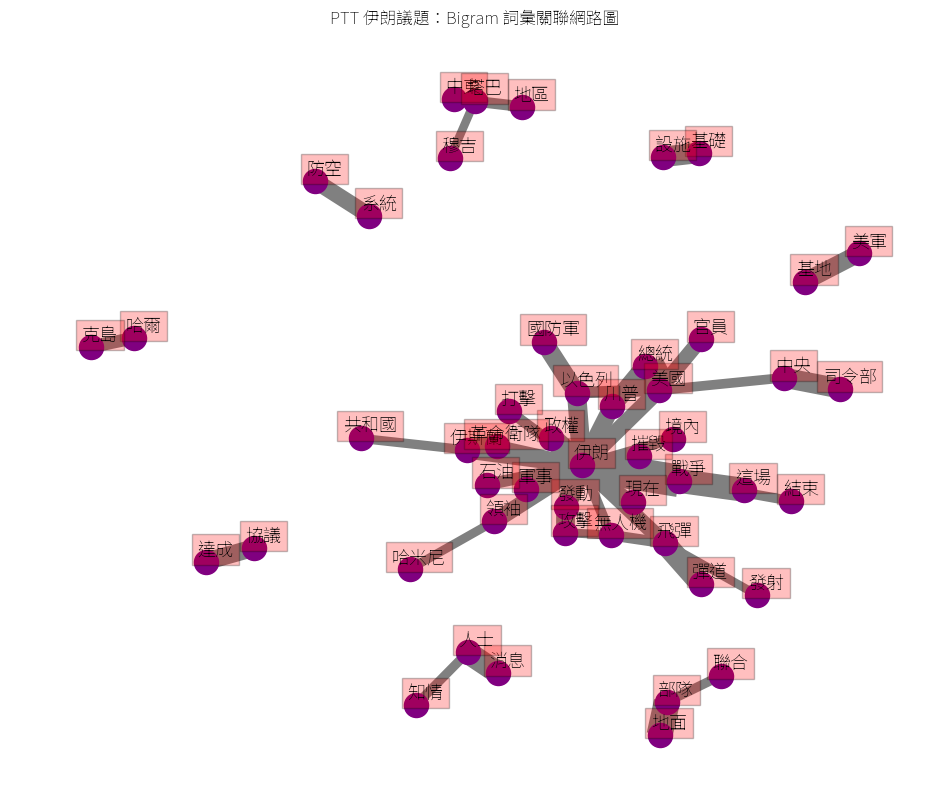

In [28]:
fig, ax = plt.subplots(figsize=(12, 10))

# 設定布局演算法
pos = nx.spring_layout(G, k=1.5)

# 繪製網路基礎線條與節點
nx.draw_networkx(G, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='purple',
                 with_labels=False,
                 ax=ax)

# 增加標籤與邊框設定
for key, value in pos.items():
    x, y = value[0] + 0.02, value[1] + 0.02
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=13)

plt.title("PTT 伊朗議題：Bigram 詞彙關聯網路圖")
plt.axis('off')
plt.show()

####5. Pairwise correlation

######準備相關性分析資料

In [29]:
# 1. 準備資料
ptt_cor_df = word_df.groupby('doc')['word'].apply(lambda x: ' '.join(map(str, x))).reset_index()
ptt_cor_df.columns = ['doc', 'word']

# 2. 建立 DTM
# 這裡加入一個關鍵參數 token_pattern，強制過濾掉長度小於 2 的英文（如 cc, my）
vectorizer = CountVectorizer(
    min_df=5,
    max_features=300,
    token_pattern=r'(?u)\b[^\d\W]{2,}\b' # 只抓長度 2 以上且非數字的詞
)
X = vectorizer.fit_transform(ptt_cor_df["word"])
vocabulary = vectorizer.get_feature_names_out()

# 3. 轉成 DataFrame
DTM_df = pd.DataFrame(columns=vocabulary, data=X.toarray())

In [30]:
# 1. 計算詞之間的相關係數 (對 DTM 轉置後計算)
corr_matrix = np.corrcoef(DTM_df.T)

# 2. 轉成 DataFrame 並整理格式
Cor_df = pd.DataFrame(corr_matrix, index=DTM_df.columns, columns=DTM_df.columns)
Cor_df.insert(0, 'word1', Cor_df.columns)
Cor_df.reset_index(inplace=True, drop=True)

# 3. 將寬表格轉為長表格 (Melt)
word_cor_df = Cor_df.melt(id_vars='word1', var_name='word2', value_name='cor')

# 4. 去除「自己跟自己相關 (cor=1)」的情況
word_cor_df = word_cor_df[word_cor_df["word1"] != word_cor_df["word2"]]

# 5. 去除重複配對
# 透過字串排序比較，確保每組配對只出現一次
word_cor_df = word_cor_df[word_cor_df['word1'] < word_cor_df['word2']]

# 6. 查看結果
print("--- 詞彙相關性排名---")
word_cor_df.sort_values('cor', ascending=False).head(10)

--- 詞彙相關性排名---


,word1,word2,cor
19511,中央,司令部,0.947926
89904,真主黨,黎巴嫩,0.906658
61275,國防軍,真主黨,0.895281
89775,國防軍,黎巴嫩,0.860630
89291,發射,飛彈,0.828091
61224,以色列,真主黨,0.828070
22524,以色列,國防軍,0.825388
69204,真主黨,聲稱,0.814456
82428,聯合,部隊,0.809016
89724,以色列,黎巴嫩,0.789944


#####5.1 關鍵詞相關性視覺化 (以「伊朗」與「以色列」為例)

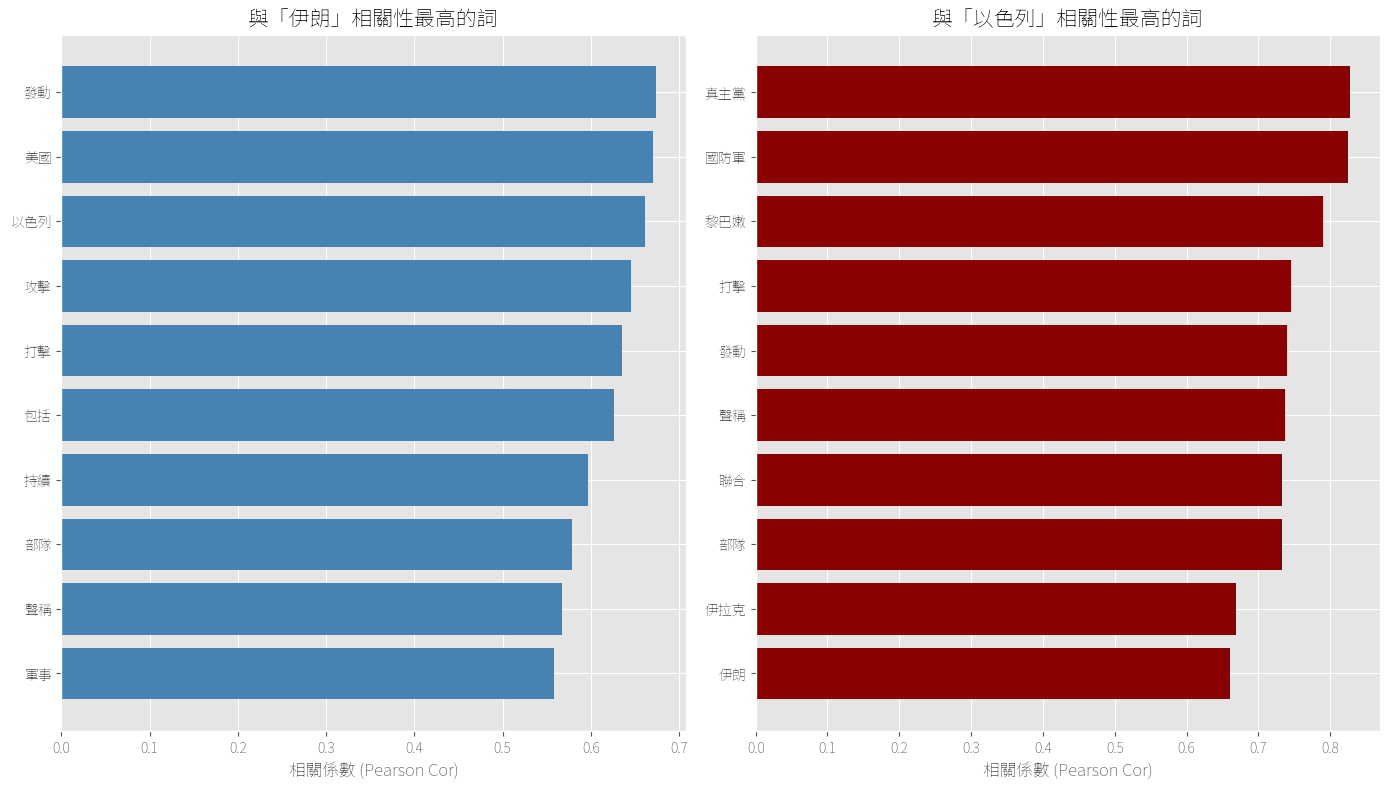

In [31]:
# 定義一個函式來獲取特定詞彙的相關性排行榜
def get_top_correlations(df, target_word, n=10):
    # 1. 篩選出 word1 或 word2 包含目標詞的列
    mask = (df['word1'] == target_word) | (df['word2'] == target_word)
    filtered = df[mask].copy()
    
    # 2. 建立新欄位 'related_word'，把「不是目標詞」的那一邊抓出來
    filtered['related_word'] = filtered.apply(
        lambda x: x['word2'] if x['word1'] == target_word else x['word1'], axis=1
    )
    
    # 3. 排序並取前 n 名
    return filtered.sort_values(by='cor', ascending=False).head(n)

# --- 執行篩選 ---
iran_cor = get_top_correlations(word_cor_df, "伊朗")
israel_cor = get_top_correlations(word_cor_df, "以色列")

# --- 設定繪圖格式 ---
plt.figure(figsize=(14, 8))
plt.style.use("ggplot")

# --- 左圖：伊朗 ---
plt.subplot(121)
plt.title('與「伊朗」相關性最高的詞', fontsize=15, fontweight='bold')
plt.xlabel('相關係數 (Pearson Cor)')
# 注意這裡改用 'related_word'
plt.barh(iran_cor['related_word'], iran_cor['cor'], color="steelblue")
plt.gca().invert_yaxis()

# --- 右圖：以色列 ---
plt.subplot(122)
plt.title('與「以色列」相關性最高的詞', fontsize=15, fontweight='bold')
plt.xlabel('相關係數 (Pearson Cor)')
# 注意這裡改用 'related_word'
plt.barh(israel_cor['related_word'], israel_cor['cor'], color="darkred")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#####5.2 使用詞彙關係圖畫出以詞頻前60為節點且相關性高於0.3的組合

In [32]:
# 1. 透過 DTM 找出詞頻前 60 高的詞彙
most_freq_df = DTM_df.sum().sort_values(ascending=False).head(60).reset_index()
most_freq_df.columns = ['word', 'count']
most_freq_word = most_freq_df['word'].tolist()

# 2. 保留「兩個詞都在前 60 名」且「相關係數 > 0.3」的組合
filtered_df = word_cor_df[
    (word_cor_df['word1'].isin(most_freq_word)) &
    (word_cor_df['word2'].isin(most_freq_word)) &
    (word_cor_df['cor'] > 0.3)
].reset_index(drop=True)

# 檢查一下篩選後的資料量
print(f"篩選後的連結數量：{len(filtered_df)}")
filtered_df.head()

篩選後的連結數量：455


,word1,word2,cor
0,人士,以色列,0.357904
1,中東,伊朗,0.348325
2,人士,伊朗,0.378338
3,以色列,伊朗,0.661057
4,伊朗,協議,0.381432


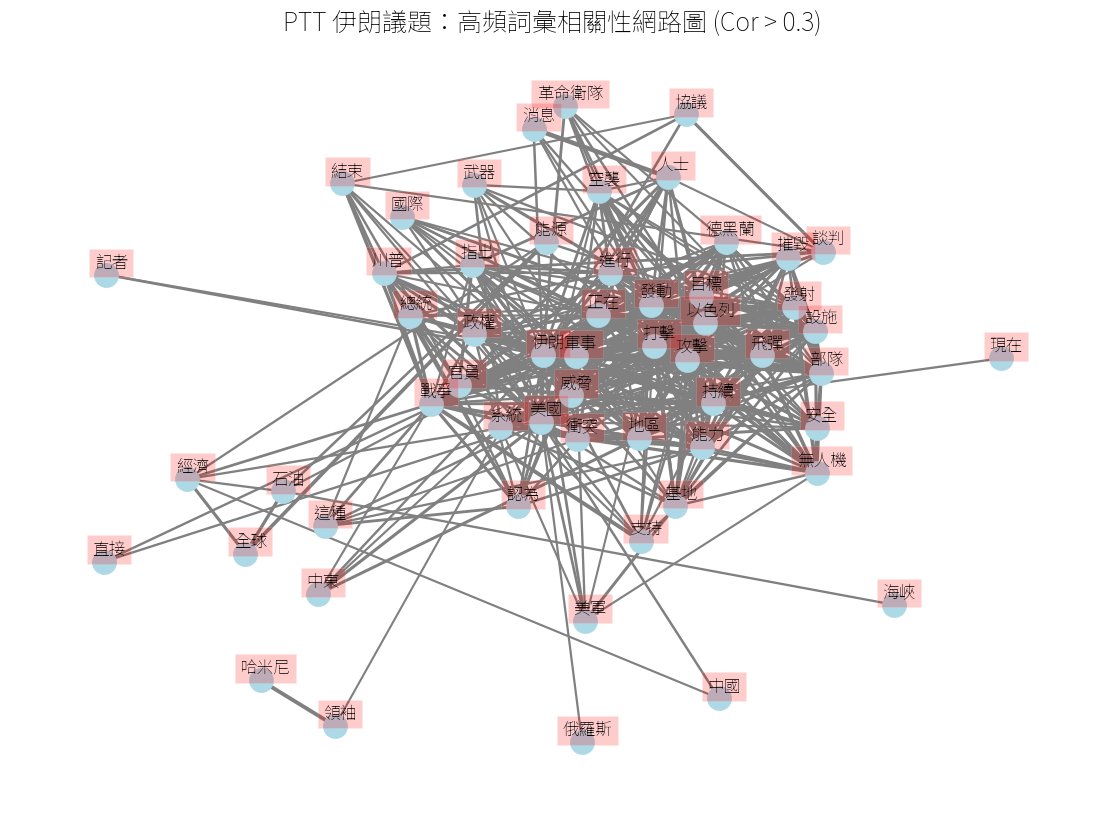

In [33]:
# 1. 建立 Graph 物件
g = nx.Graph()

# 2. 建立節點與連線
for i in range(len(filtered_df)):
    g.add_edge(filtered_df["word1"][i], filtered_df["word2"][i], weight=filtered_df["cor"][i])

# 3. 根據相關係數決定線條粗細 (乘上 5 倍是為了讓差異明顯)
weights = [w[2]['weight'] * 5 for w in g.edges(data=True)]

# 4. 繪製圖形
fig, ax = plt.subplots(figsize=(14, 10))

# k 值決定節點間的斥力
pos = nx.spring_layout(g, k=0.8, seed=42)

# 繪製網路基礎
nx.draw_networkx(g, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='lightblue',
                 with_labels=False,
                 ax=ax)

# 增加標籤與半透明紅底背景
for key, value in pos.items():
    x, y = value[0] + 0.01, value[1] + 0.02
    ax.text(x, y, s=key,
            bbox=dict(facecolor='red', alpha=0.2),
            horizontalalignment='center', fontsize=12)

plt.title("PTT 伊朗議題：高頻詞彙相關性網路圖 (Cor > 0.3)", fontsize=18)
plt.axis('off')
plt.show()

####6. 計算文章相似度

In [34]:
clean_content = word_df.groupby('doc')['word'].apply(lambda x: ' '.join(map(str, x)))

# 建立一個同步的資料表 (包含標題、網址、內容)
data_cos = df.loc[clean_content.index, ["artTitle", "artUrl"]].copy()
data_cos['word'] = clean_content.values

data_cos = data_cos.reset_index(drop=True)

X = vectorizer.fit_transform(data_cos["word"])

In [35]:
# 1. 將 tfidf 改成 X (對應你上一單元的輸出變數)
cos_df = pd.DataFrame(cosine_similarity(X, X)[0], columns=['cos_similarity'])

# 2. 合併文章資訊
cos_df = cos_df.merge(data_cos, left_index=True, right_index=True)

# 3. 排序看前 10 名
print(f"--- 與第一篇文章《{data_cos.iloc[0]['artTitle']}》最相似的 Top 10 ---")
display(cos_df.sort_values(by=['cos_similarity'], ascending=False).head(10))

--- 與第一篇文章《[新聞] 保護伊朗人員前來　巴基斯坦空軍闢安全》最相似的 Top 10 ---


,cos_similarity,artTitle,artUrl,word
0,1.000000,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,https://www.ptt.cc/bbs/Military/M.1775823165.A...,出處 摘要 中央社 新德里 綜合 外電 美國 伊朗 將於日 巴基斯坦 首都 伊斯蘭 巴德 舉...
1529,0.742307,[問卦] 台灣為什麼不當美國跟伊朗的和事佬,https://www.ptt.cc/bbs/Gossiping/M.1774838868....,最近 美國 伊朗 打起來 協助 調停 巴基斯坦 台灣 不像 巴基斯坦 和事佬 角色
298,0.735631,[新聞] 巴基斯坦：美、伊朗談判「進行中」,https://www.ptt.cc/bbs/Military/M.1774540153.A...,和事佬 出面 證實 巴基斯坦 伊朗 談判 進行 伊朗 一再 否認 美國 談判 結束 戰爭 居...
253,0.643939,[情報] 巴基斯坦外長稱伊朗與美國已同意進行談判,https://www.ptt.cc/bbs/Military/M.1774806708.A...,巴基斯坦 外長 沙克 達爾 巴基斯坦 伊朗 美國 雙方 表達 巴基斯坦 促成 對話 信任 感...
719,0.642931,Re: [情報] 沙烏地要求巴基斯坦加入對伊朗戰爭,https://www.ptt.cc/bbs/Military/M.1772691671.A...,沙國 王儲 要求 巴基斯坦 加入 伊朗 戰爭 取消 沙巴 雙邊 安全 協議 伊朗 真要 這篇...
54,0.639763,[情報] 伊朗證實川普已同意伊朗10點為談判基礎,https://www.ptt.cc/bbs/Military/M.1775605096.A...,伊朗 官方 證實 達成 兩週 停火 協議 指出 川普 同意 伊朗 提出 的點 條件 雙方 後...
14,0.630952,[新聞] 美伊談判生變？伊朗大使刪除伊朗代表團將,https://www.ptt.cc/bbs/Military/M.1775719468.A...,美伊 談判 生變 伊朗 大使 伊朗 代表團 抵達 巴基斯坦 貼文 聯合報 大陸 中心 即時 ...
260,0.625846,[新聞] 巴基斯坦與伊朗達成協議 20艘巴國船隻可,https://www.ptt.cc/bbs/Military/M.1774759027.A...,原文 原文 摘要 中東 戰火 持續 延燒 伊朗 實質 封鎖 荷姆茲海峽 這也 造成 全球 油...
720,0.606161,[情報] 沙烏地要求巴基斯坦加入對伊朗戰爭,https://www.ptt.cc/bbs/Military/M.1772690582.A...,沙國 王儲 要求 巴基斯坦 加入 伊朗 戰爭 取消 沙巴 雙邊 安全 協議 伊朗 真要
986,0.599491,[問卦] 伊朗其實不是落後國家的八卦？,https://www.ptt.cc/bbs/Gossiping/M.1775625857....,伊朗 伊斯蘭 共和國 波斯語 通稱 伊朗 波斯語 外界 稱為 波斯 地處 西亞 伊朗 高原 ...


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

# 關鍵補位：先計算整張相似度矩陣 (這會得到一個 文章數 x 文章數 的矩陣)
cosine_matrix = cosine_similarity(X)

# --- 以下是你原本的觀察程式碼 ---
target_index = 14 # 觀察第 15 篇文章 (Index 從 0 開始)

cos_df_target = pd.DataFrame(cosine_matrix[target_index], columns=['cos_similarity'])
cos_df_target = cos_df_target.merge(data_cos, how='left', left_index=True, right_index=True)

print(f"--- 與第 {target_index} 篇文章最相似的內容 ---")
print(f"目標文章標題：{data_cos.iloc[target_index]['artTitle']}")

# 排序並顯示結果
display(cos_df_target.loc[:,["cos_similarity", "artTitle", "artUrl"]]
        .sort_values(by=['cos_similarity'], ascending=False).head(10))

--- 與第 14 篇文章最相似的內容 ---
目標文章標題：[新聞] 美伊談判生變？伊朗大使刪除伊朗代表團將


,cos_similarity,artTitle,artUrl
14,1.000000,[新聞] 美伊談判生變？伊朗大使刪除伊朗代表團將,https://www.ptt.cc/bbs/Military/M.1775719468.A...
961,0.773237,[問卦] 伊朗是不是打不過以色列啊,https://www.ptt.cc/bbs/Gossiping/M.1775668128....
962,0.758426,[新聞] 快訊》美伊難講和 伊朗威脅退出！,https://www.ptt.cc/bbs/Gossiping/M.1775664939....
939,0.752030,[新聞] 以色列空襲黎巴嫩釀250餘死 伊朗警告再轟,https://www.ptt.cc/bbs/Gossiping/M.1775728228....
23,0.750249,Re: [情報] 伊朗媒體稱以軍繼續轟炸黎巴嫩將導致伊朗退出停火,https://www.ptt.cc/bbs/Military/M.1775673468.A...
2147,0.737022,[問卦] 美吹說伊朗恐怖份子 但支持以色列殺人？,https://www.ptt.cc/bbs/Gossiping/M.1773763072....
987,0.732958,[新聞] 美伊各自宣布大獲全勝！伊朗持續與以色,https://www.ptt.cc/bbs/Gossiping/M.1775625742....
10,0.731247,[情報] 伊朗副外長稱巴基斯坦說服己方別重啟戰端,https://www.ptt.cc/bbs/Military/M.1775757443.A...
20,0.717071,[情報] ISW 伊朗最新情勢特別報告，2026年4月8日,https://www.ptt.cc/bbs/Military/M.1775698357.A...
1213,0.708683,[問卦] 會給伊朗respect的舉手,https://www.ptt.cc/bbs/Gossiping/M.1775303818....
